=== SANITY CHECK ===
Di = 7.800 m
A  = 2.481858 m^2
I  = 1.936470e+01 m^4
EI = 4.066587e+12 N m^2
m_struct = 19482.587 kg/m
m_added  = 51522.120 kg/m (Ca=1.0)
m1 (sub) = 71004.706 kg/m
m2 (air) = 19482.587 kg/m
P (compression) = 0.000e+00 N
c used in K(ω)   = 0.000 N s/m

First 3 modes with ω < 20 rad/s:
  NONE found under 20 rad/s with current parameters / model.


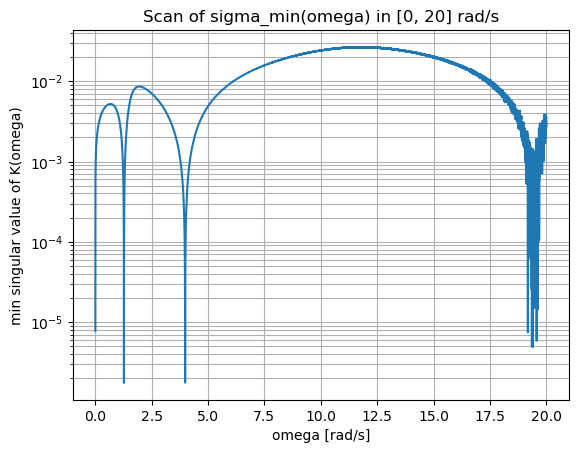

In [9]:
# ============================================================
# COMPLETE WORKING SCRIPT
# - Builds 2-segment Euler–Bernoulli model (submerged + above water)
# - Assembles 8 BC/interface equations into K(ω)
# - Finds FIRST 3 natural frequencies with ω < 20 rad/s
#   using min singular value of K(ω) + SciPy bounded minimization
# - Plots the FIRST 3 modal shapes
#
# Notes:
# - Compression is modeled as P >= 0 in: EI W'''' - P W'' - ω^2 m W = 0
# - For "natural frequencies" set damping c = 0.0 (default below)
# - If you do not want added mass: set Ca = 0.0
# - P_val is NOT in your parameter table; set it to your axial compressive load (N) or 0.0
# ============================================================

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# -------------------------
# 1) SYMBOLS
# -------------------------
z = sp.Symbol("z", real=True)
omega = sp.Symbol("omega", positive=True, real=True)

EI, h, H = sp.symbols("EI h H", positive=True, real=True)
P = sp.Symbol("P", nonnegative=True, real=True)          # axial compression (N), P>=0
m1, m2 = sp.symbols("m1 m2", positive=True, real=True)   # line mass (kg/m) per segment

Mtip, J, c = sp.symbols("Mtip J c", nonnegative=True, real=True)  # tip mass, rot inertia, damping

A1, B1, C1, D1, A2, B2, C2, D2 = sp.symbols("A1 B1 C1 D1 A2 B2 C2 D2", real=True)

# -------------------------
# 2) CHARACTERISTIC PARAMETERS (compression form)
# EI W'''' - P W'' - ω^2 m W = 0
# λ^4 - (P/EI) λ^2 - (ω^2 m/EI) = 0
# => λ = ±a (real) and λ = ± i μ (imag) with:
# a^2 = (P/EI + sqrt((P/EI)^2 + 4β^4))/2
# μ^2 = (-P/EI + sqrt((P/EI)^2 + 4β^4))/2
# β^4 = ω^2 m/EI
# -------------------------
def a_mu(m_line):
    beta4 = omega**2 * m_line / EI
    disc = sp.sqrt((P/EI)**2 + 4*beta4)
    a2 = ((P/EI) + disc) / 2
    mu2 = (-(P/EI) + disc) / 2
    return sp.sqrt(a2), sp.sqrt(mu2)

a1, mu1 = a_mu(m1)
a2, mu2 = a_mu(m2)

# -------------------------
# 3) GENERAL SOLUTIONS
# -------------------------
W1 = A1*sp.cosh(a1*z) + B1*sp.sinh(a1*z) + C1*sp.cos(mu1*z) + D1*sp.sin(mu1*z)
W2 = A2*sp.cosh(a2*z) + B2*sp.sinh(a2*z) + C2*sp.cos(mu2*z) + D2*sp.sin(mu2*z)

W1_1, W1_2, W1_3 = sp.diff(W1, z), sp.diff(W1, z, 2), sp.diff(W1, z, 3)
W2_1, W2_2, W2_3 = sp.diff(W2, z), sp.diff(W2, z, 2), sp.diff(W2, z, 3)

# Internal forces consistent with EI W'''' - P W'' - ω^2 m W = 0
# Moment:   M = EI W''
# Shear:    V = EI W''' - P W'
M1_expr, M2_expr = EI*W1_2, EI*W2_2
V1_expr, V2_expr = EI*W1_3 - P*W1_1, EI*W2_3 - P*W2_1

# -------------------------
# 4) BC + INTERFACE (8 equations, LHS=0)
# -------------------------
# clamped at z=-h
eq1 = W1.subs(z, -h)
eq2 = W1_1.subs(z, -h)

# interface at z=0: continuity of W, W', M, V
eq3 = W1.subs(z, 0) - W2.subs(z, 0)
eq4 = W1_1.subs(z, 0) - W2_1.subs(z, 0)
eq5 = M1_expr.subs(z, 0) - M2_expr.subs(z, 0)
eq6 = V1_expr.subs(z, 0) - V2_expr.subs(z, 0)

# tip at z=H:
# rotational inertia BC (correct sign): EI W'' - J ω^2 W' = 0
eq7 = EI*W2_2.subs(z, H) - J*omega**2*W2_1.subs(z, H)

# force BC with translational tip mass + translational damper:
# EI W''' - P W' - M ω^2 W + i c ω W = 0
eq8 = (EI*W2_3.subs(z, H) - P*W2_1.subs(z, H)
       - Mtip*omega**2*W2.subs(z, H) + sp.I*c*omega*W2.subs(z, H))

eqs = [eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8]
Cvec = sp.Matrix([A1, B1, C1, D1, A2, B2, C2, D2])

K = sp.Matrix([[sp.diff(expr, cst) for cst in Cvec] for expr in eqs])

# -------------------------
# 5) NUMERICAL INPUT (your table + explicit assumptions)
# -------------------------
# Given (from your screenshot)
h_val = 35.0          # m
H_val = 150.0         # m
D_val = 8.0           # m
t_val = 0.1           # m
Mtip_val = 1000e3     # kg  (1000 ton)
J_val = 1.6e10        # kg m^2
c_val = 30e3          # N s/m (30 kN s/m)

# Material assumptions (steel)
E_val = 210e9         # Pa
rho_steel = 7850.0    # kg/m^3

# Fluid added mass assumptions (optional)
rho_water = 1025.0    # kg/m^3
Ca = 1.0              # added mass coefficient; set 0.0 if you want none

# Axial compression (NOT in your table!) -> set as needed
P_val = 0.0           # N   <-- change if you have compressive load

# Natural frequencies: set damping to 0
c_for_modes = 0.0     # set to c_val if you intentionally want damping in K(ω)

# Cross-section hollow circular
Di_val = D_val - 2.0*t_val
A_val = (np.pi/4.0)*(D_val**2 - Di_val**2)
I_val = (np.pi/64.0)*(D_val**4 - Di_val**4)
EI_val = E_val * I_val

# Line masses
m_struct = rho_steel * A_val
m_added = rho_water * Ca * (np.pi*D_val**2/4.0)
m_sub = m_struct + m_added
m_air = m_struct

print("=== SANITY CHECK ===")
print(f"Di = {Di_val:.3f} m")
print(f"A  = {A_val:.6f} m^2")
print(f"I  = {I_val:.6e} m^4")
print(f"EI = {EI_val:.6e} N m^2")
print(f"m_struct = {m_struct:.3f} kg/m")
print(f"m_added  = {m_added:.3f} kg/m (Ca={Ca})")
print(f"m1 (sub) = {m_sub:.3f} kg/m")
print(f"m2 (air) = {m_air:.3f} kg/m")
print(f"P (compression) = {P_val:.3e} N")
print(f"c used in K(ω)   = {c_for_modes:.3f} N s/m")
print("====================\n")

par = {
    EI: EI_val,
    h: h_val,
    H: H_val,
    P: P_val,
    m1: m_sub,
    m2: m_air,
    Mtip: Mtip_val,
    J: J_val,
    c: c_for_modes,
}

# -------------------------
# 6) NUMERIC K(ω) AND sigma_min(ω)
# -------------------------
K_sub = sp.Matrix(K).subs(par)
K_fun = sp.lambdify(omega, K_sub, "numpy")

def Knum(w):
    return np.array(K_fun(w), dtype=np.complex128)

def sigma_min(w):
    s = np.linalg.svd(Knum(w), compute_uv=False)
    return float(np.min(s))

# -------------------------
# 7) FIND FIRST 3 MODES WITH ω < 20 rad/s
# -------------------------
def find_first_n_modes_below(w_max=20.0, n_modes=3, n_grid=15000, sigma_tol=1e-6):
    ws = np.linspace(1e-6, w_max, n_grid)
    sig = np.array([sigma_min(w) for w in ws], dtype=float)

    modes = []
    for i in range(1, len(ws)-1):
        if sig[i] < sig[i-1] and sig[i] < sig[i+1]:
            a, b = ws[i-1], ws[i+1]
            res = minimize_scalar(lambda w: sigma_min(w), bounds=(a, b), method="bounded")
            w_star = float(res.x)
            s_star = float(sigma_min(w_star))

            if s_star < sigma_tol:
                if all(abs(w_star - w0) > 1e-2 for w0 in modes):
                    modes.append(w_star)
                    if len(modes) >= n_modes:
                        break

    return np.array(modes), ws, sig

omegas_3, ws_scan, sig_scan = find_first_n_modes_below(
    w_max=20.0, n_modes=3, n_grid=18000, sigma_tol=1e-8
)

print("First 3 modes with ω < 20 rad/s:")
if len(omegas_3) == 0:
    print("  NONE found under 20 rad/s with current parameters / model.")
else:
    for k, w in enumerate(omegas_3, 1):
        print(f"  mode {k}: omega = {w:.6f} rad/s   f = {w/(2*np.pi):.6f} Hz   sigma_min={sigma_min(w):.3e}")

# Optional: view scan (log scale helps)
plt.figure()
plt.plot(ws_scan, sig_scan)
plt.yscale("log")
plt.xlabel("omega [rad/s]")
plt.ylabel("min singular value of K(omega)")
plt.grid(True, which="both")
plt.title("Scan of sigma_min(omega) in [0, 20] rad/s")
plt.show()

# -------------------------
# 8) MODAL SHAPES FOR THE FIRST 3 OMEGAS
#    Use SVD null-vector C from K(ω) C = 0
# -------------------------
W1_sub = sp.simplify(W1.subs(par))
W2_sub = sp.simplify(W2.subs(par))

W1_fun = sp.lambdify((z, omega, A1, B1, C1, D1, A2, B2, C2, D2), W1_sub, "numpy")
W2_fun = sp.lambdify((z, omega, A1, B1, C1, D1, A2, B2, C2, D2), W2_sub, "numpy")

def mode_constants_from_svd(w):
    Kw = Knum(w)
    U, S, Vh = np.linalg.svd(Kw)
    C = Vh.conj().T[:, -1]  # right singular vector for smallest singular value
    C = C / (np.max(np.abs(C)) + 1e-16)
    return C

def eval_mode_shape(w, npts=800):
    C = mode_constants_from_svd(w)
    A1v,B1v,C1v,D1v,A2v,B2v,C2v,D2v = C

    z1 = np.linspace(-h_val, 0.0, npts//2, endpoint=True)
    z2 = np.linspace(0.0, H_val,  npts//2, endpoint=True)

    Wz1 = W1_fun(z1, w, A1v,B1v,C1v,D1v,A2v,B2v,C2v,D2v)
    Wz2 = W2_fun(z2, w, A1v,B1v,C1v,D1v,A2v,B2v,C2v,D2v)

    z_all = np.concatenate([z1, z2[1:]])   # avoid duplicate point at 0
    W_all = np.concatenate([Wz1, Wz2[1:]])

    W_plot = np.real(W_all)                # natural modes (c=0) should be ~real
    W_plot /= (np.max(np.abs(W_plot)) + 1e-16)

    return z_all, W_plot

if len(omegas_3) > 0:
    for i, w in enumerate(omegas_3[:3], 1):
        z_plot, W_plot = eval_mode_shape(float(w), npts=1000)

        plt.figure()
        plt.plot(z_plot, W_plot)
        plt.axvline(0.0, linewidth=1)
        plt.grid(True)
        plt.xlabel("z [m]   (segment 1: -h..0, segment 2: 0..H)")
        plt.ylabel("Normalized W(z)")
        plt.title(f"Mode {i}: omega = {w:.6f} rad/s  (f = {w/(2*np.pi):.6f} Hz)")
        plt.show()